# BBC News Dataset — Exploratory Data Analysis
**Dataset:** `bigquery-public-data.bbc_news.fulltext`  
**Categories:** business, entertainment, politics, sport, tech  
**Goal:** Understand data structure, class distribution, text characteristics  
before building the training pipeline

In [1]:
from google.cloud import bigquery
import logging
import pyarrow as pa
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

logging.basicConfig(level=logging.INFO)

In [3]:
PROJECT = "cs-cdwp-data-dev2188"
TABLE   = "bigquery-public-data.bbc_news.fulltext"

client = bigquery.Client(project=PROJECT)
print("Connected to BigQuery ✅")

Connected to BigQuery ✅


In [4]:
table = client.get_table(TABLE)

print(f"Table: {table.full_table_id}")
print(f"Rows:  {table.num_rows:,}")
print(f"Size:  {table.num_bytes / 1024 / 1024:.1f} MB")
print(f"\nSchema:")
for field in table.schema:
    print(f"  {field.name:<20} {field.field_type:<10} {field.description or ''}")

Table: bigquery-public-data:bbc_news.fulltext
Rows:  2,225
Size:  17.9 MB

Schema:
  body                 STRING     
  title                STRING     
  filename             STRING     
  category             STRING     
  body_embedded        FLOAT      


In [5]:
query = f"""
    SELECT body, title, filename, category
    FROM `{TABLE}`
    LIMIT 5
"""
sample = client.query(query).to_dataframe()
print(sample)

                                                body  \
0  News Corp, the media company controlled by Aus...   
1  Millions of the world's poorest textile trade ...   
2  The board of Indian conglomerate Reliance has ...   
3  German airline Lufthansa may sue federal agenc...   
4  General Motors (GM) saw its net profits fall 3...   

                               title              filename  category  
0  News Corp eyes video games market  bbc/business/254.txt  business  
1    Millions 'to lose textile jobs'  bbc/business/296.txt  business  
2  Share boost for feud-hit Reliance  bbc/business/352.txt  business  
3  Lufthansa may sue over Bush visit  bbc/business/064.txt  business  
4   European losses hit GM's profits  bbc/business/467.txt  business  


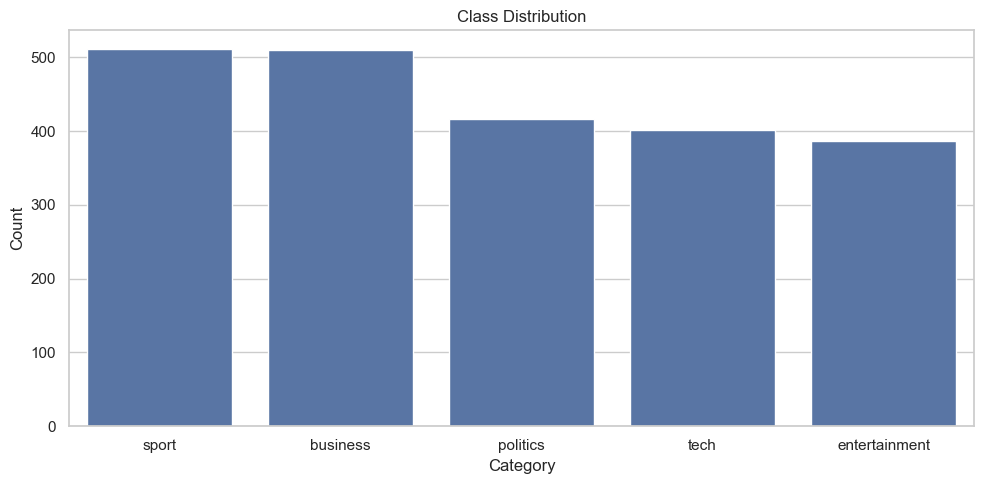

        category  count
0          sport    511
1       business    510
2       politics    417
3           tech    401
4  entertainment    386


In [6]:
query = f"""
    SELECT category, COUNT(*) as count
    FROM `{TABLE}`
    GROUP BY category
    ORDER BY count DESC
"""

dist = client.query(query).to_dataframe()

fig, ax = plt.subplots()
sns.barplot(data=dist, x="category", y="count", ax=ax)
ax.set_title("Class Distribution")
ax.set_xlabel("Category")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(dist)

In [7]:
query = f"""
    SELECT 
        category,
        AVG(LENGTH(body))    as avg_chars,
        MAX(LENGTH(body))    as max_chars,
        MIN(LENGTH(body))    as min_chars,
        AVG(ARRAY_LENGTH(SPLIT(body, ' '))) as avg_words
    FROM `{TABLE}`
    GROUP BY category
    ORDER BY category
"""

lengths = client.query(query).to_dataframe()
lengths

,category,avg_chars,max_chars,min_chars,avg_words
0,business,1952.762745,5373,816,320.274510
1,entertainment,1894.699482,19104,791,321.901554
2,politics,2650.592326,25453,470,444.671463
3,sport,1865.023483,9437,687,320.970646
4,tech,2943.024938,16126,942,493.164589


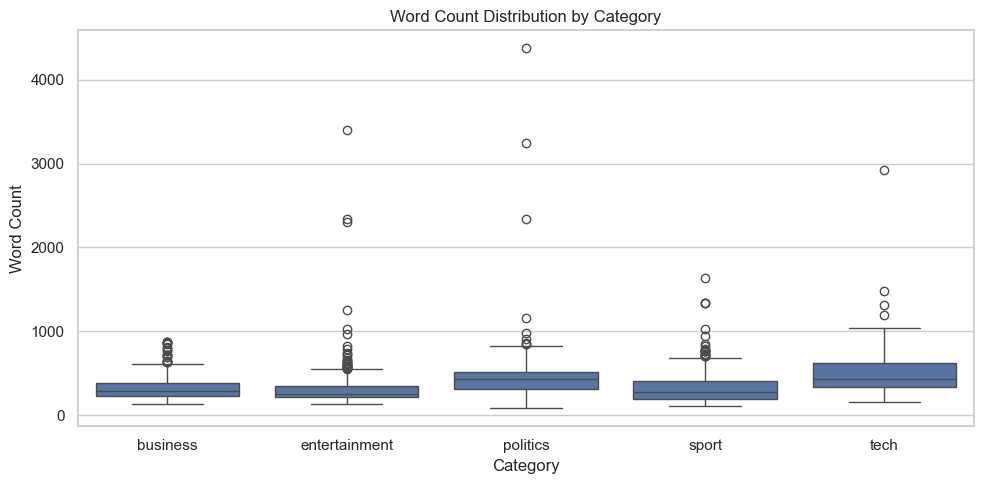

In [8]:
query = f"""
    SELECT 
        category,
        ARRAY_LENGTH(SPLIT(body, ' ')) as word_count
    FROM `{TABLE}`
"""

words = client.query(query).to_dataframe()

fig, ax = plt.subplots()
sns.boxplot(data=words, x="category", y="word_count", ax=ax)
ax.set_title("Word Count Distribution by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Word Count")
plt.tight_layout()
plt.show()

In [9]:
query = f"""
    SELECT 
        COUNTIF(body IS NULL)     as null_body,
        COUNTIF(title IS NULL)    as null_title,
        COUNTIF(category IS NULL) as null_category,
        COUNTIF(LENGTH(body) < 100) as very_short_body
    FROM `{TABLE}`
"""

quality = client.query(query).to_dataframe()
print("Data Quality Check:")
quality

Data Quality Check:


,null_body,null_title,null_category,very_short_body
0,0,0,0,0


In [10]:
query = f"""
    SELECT category, title, LEFT(body, 300) as body_preview
    FROM (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY category ORDER BY RAND()) as rn
        FROM `{TABLE}`
    )
    WHERE rn = 1
    ORDER BY category
"""

samples = client.query(query).to_dataframe()
for _, row in samples.iterrows():
    print(f"\n{'='*60}")
    print(f"Category : {row['category']}")
    print(f"Title    : {row['title']}")
    print(f"Preview  : {row['body_preview'][:200]}")


Category : business
Title    : Brazil buy boosts Belgium's Inbev
Preview  : Belgian brewing giant Inbev has seen its profits soar thanks to its acquisition of Brazil's biggest beer firm Ambev last year.

Inbev, which makes Stella Artois, said pre-tax profits for 2004 rose 56%

Category : entertainment
Title    : Actor Foxx sees Globe nominations
Preview  : US actor Jamie Foxx has been given two nominations for Golden Globe awards, with Meryl Streep, Morgan Freeman and Cate Blanchett also up for prizes.

The stars were shortlisted on Monday for supportin

Category : politics
Title    : Probe launched on Ken Nazi jibe
Preview  : An investigation by the Standards Board is under way following allegations that Ken Livingstone has brought his office into disrepute.

The probe follows the London mayor's comments to a Jewish journa

Category : sport
Title    : Farrell saga to drag on - Lindsay
Preview  : Wigan chairman Maurice Lindsay says he does not expect a quick solution to the on-going s